## Week 1 – Monthly Dataset Aggregation
Individual monthly files are combined into unified datasets that span multiple months, enabling trend
analysis over time.

### Objective
Load and concatenate all monthly MLS files from January 2024 through the most recently completed
calendar month into analysis-ready combined datasets.

### Outputs
- Combined sold transactions dataset
- Combined listing data dataset

### Skills Learned
- Multi-file dataset management
- Data aggregation with Pandas
- Preparing time-series datasets for analysis


In [ ]:
# This line just hides warning messages so we can focus on the results—but we only use it when we understand what those warnings mean.
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np
import glob
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# Turn off scientific notation
pd.set_option('display.float_format', '{:.2f}'.format)

In [ ]:
data_path = Path("/Users/sarahbarah3/Desktop/crmls")
save_path = Path("/Users/sarahbarah3/Desktop/crmls/combined")

In [ ]:
def read_csv_with_fallback(filepath):
    """Read CSV with UTF-8, fallback to cp1252 if needed."""
    try:
        df = pd.read_csv(filepath, encoding="utf-8")
        return df, "utf-8"
    except UnicodeDecodeError:
        df = pd.read_csv(filepath, encoding="cp1252")
        return df, "cp1252"

### Define lists

In [ ]:
listing_files = list(data_path.glob("CRMLSListing*.csv"))
sold_files = list(data_path.glob("CRMLSSold*.csv"))

In [ ]:
print(list(data_path.glob("*.csv")))

[PosixPath('/Users/sarahbarah3/Desktop/crmls/CRMLSSold202404_filled.csv'), PosixPath('/Users/sarahbarah3/Desktop/crmls/CRMLSSold202409.csv'), PosixPath('/Users/sarahbarah3/Desktop/crmls/CRMLSListing202405.csv'), PosixPath('/Users/sarahbarah3/Desktop/crmls/CRMLSListing202411.csv'), PosixPath('/Users/sarahbarah3/Desktop/crmls/CRMLSListing202410.csv'), PosixPath('/Users/sarahbarah3/Desktop/crmls/CRMLSListing202404.csv'), PosixPath('/Users/sarahbarah3/Desktop/crmls/CRMLSSold202408.csv'), PosixPath('/Users/sarahbarah3/Desktop/crmls/CRMLSListing202412.csv'), PosixPath('/Users/sarahbarah3/Desktop/crmls/CRMLSListing202406.csv'), PosixPath('/Users/sarahbarah3/Desktop/crmls/CRMLSListing202407.csv'), PosixPath('/Users/sarahbarah3/Desktop/crmls/priceratio.csv'), PosixPath('/Users/sarahbarah3/Desktop/crmls/CRMLSSold202501_filled.csv'), PosixPath('/Users/sarahbarah3/Desktop/crmls/CRMLSListing202601.csv'), PosixPath('/Users/sarahbarah3/Desktop/crmls/CRMLSListing202403.csv'), PosixPath('/Users/sarahba

### Read and Concatenate

In [ ]:
full_listing = []
encoding_log = []
row_counts = []

for filepath in listing_files:
    df, encoding_used = read_csv_with_fallback(filepath)

    full_listing.append(df)
    encoding_log.append((filepath, encoding_used))
    row_counts.append(len(df))

# Safety check before concat
if full_listing:
    listing_combined = pd.concat(full_listing, ignore_index=True)
    print("Combined listing shape:", listing_combined.shape)
else:
    print("No listing files were loaded.")

Combined listing shape: (851298, 84)


In [ ]:
full_sold = []
encoding_log_sold = []
row_counts_sold = []

for filepath in sold_files:
    df, encoding_used = read_csv_with_fallback(filepath)

    full_sold.append(df)
    encoding_log_sold.append((filepath, encoding_used))
    row_counts_sold.append(len(df))

if full_sold:
    sold_combined = pd.concat(full_sold, ignore_index=True)
    print("Combined sold shape:", sold_combined.shape)
else:
    print("No sold files were loaded.")

Combined sold shape: (658362, 84)


In [ ]:
listing_combined.to_csv(save_path / "listing_combined.csv", index=False)
sold_combined.to_csv(save_path / "sold_combined.csv", index=False)

### View the first and last 5 rows of the listing dataset.

In [ ]:
listing_combined.head()

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerOfficeName.1,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,UnparsedAddress.1,BuyerAgencyCompensationType,BuyerAgencyCompensation
0,929000.00,1076194146,dianne@drector.com,NaN,NaN,Dianne,Rector,NaN,NaN,16882 Canyon Lane,...,2.00,Huntington Beach Union High,92649,NaN,330.00,1847.00,NaN,16882 Canyon Lane,NaN,NaN
1,999999.00,1076194026,realestateby_denisegarcia@gmail.com,NaN,NaN,Denise,Garcia,NaN,NaN,8720 S 4th Avenue,...,2.00,Inglewood Unified,90305,NaN,0.00,8508.00,NaN,8720 S 4th Avenue,NaN,NaN
2,1400000.00,1076193814,alizabethjames@hotmail.com,NaN,NaN,Alizabeth,James,33.86,-116.54,505 E Molino Road,...,2.00,Palm Springs Unified,92262,NaN,NaN,10890.00,NaN,505 E Molino Road,NaN,NaN
3,4998888.00,1076193812,ernieramos62@yahoo.com,NaN,NaN,Ernesto,Ramos,NaN,NaN,3653 Halldale Avenue,...,0.00,NaN,90018,NaN,NaN,6192.00,NaN,3653 Halldale Avenue,NaN,NaN
4,549000.00,1076193525,parsanina@yahoo.com,NaN,NaN,Nina,Parsa,NaN,NaN,1736 N Mcdivitt Avenue,...,2.00,Los Angeles Unified,90221,NaN,0.00,4113.00,NaN,1736 N Mcdivitt Avenue,NaN,NaN


In [ ]:
listing_combined.tail()

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerOfficeName.1,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,UnparsedAddress.1,BuyerAgencyCompensationType,BuyerAgencyCompensation
851293,25000.00,1061308992,robin@cbborrego.com,NaN,NaN,Robin,Reynolds,33.27,-115.95,1102 Stanford Avenue,...,NaN,NaN,92274,NaN,0.00,13503.60,NaN,1102 Stanford Avenue,NaN,NaN
851294,625000.00,1060129455,joel@ripfritzer.com,NaN,NaN,Joel,Cloud,32.77,-116.93,1725 Grove Road,...,NaN,NaN,92020,NaN,0.00,43560.00,NaN,1725 Grove Road,NaN,NaN
851295,409000.00,1058408504,marierealtor4you@gmail.com,NaN,NaN,Marie,Arredondo,33.21,-116.30,3135 Club Circle East,...,2.00,Borrego Springs Unified,92004,NaN,0.00,34848.00,NaN,3135 Club Circle East,NaN,NaN
851296,3900000.00,1038675566,brettbman@gmail.com,NaN,NaN,Brett,Baumann,37.50,-120.05,665 Acs. - Mt Bullion Cut-Off Road,...,NaN,NaN,95338,NaN,0.00,28980903.60,NaN,665 Acs. - Mt Bullion Cut-Off Road,NaN,NaN
851297,1825000.00,1038248402,taylor@willisallen.com,NaN,NaN,Taylor,Smith,32.62,-117.13,5 Bridgetown Bend,...,2.00,Coronado Unified,92118,NaN,331.00,3959.00,NaN,5 Bridgetown Bend,NaN,NaN


### View the first and last 5 rows of the sold dataset.

In [ ]:
sold_combined.head()

,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled,BuyerAgentAOR,ListAgentAOR,OriginatingSystemName,OriginatingSystemSubName
0,NaN,True,NaN,NaN,NaN,159000.00,555125771,deborah.potestio@c21selectgroup.com,2024-04-29,45000.00,...,95916,0.00,336283.20,NaN,False,False,NaN,NaN,NaN,NaN
1,NaN,True,NaN,NaN,NaN,144000.00,554271746,crchapman@sbcglobal.net,2024-04-26,78000.00,...,95966,0.00,101495.00,NaN,False,False,NaN,NaN,NaN,NaN
2,NaN,True,NaN,NaN,False,265000.00,543251400,michaelg@londonproperties.com,2024-04-02,250000.00,...,93726,0.00,8100.00,NaN,False,False,NaN,NaN,NaN,NaN
3,NaN,True,NaN,NaN,NaN,925000.00,539236677,chris.campbell@msn.com,2024-04-10,815000.00,...,92223,0.00,564988.00,NaN,False,False,NaN,NaN,NaN,NaN
4,NaN,True,NaN,NaN,NaN,25000.00,538449222,rrinder@sbcglobal.net,2024-04-06,15000.00,...,95966,0.00,6098.00,NaN,False,False,NaN,NaN,NaN,NaN


In [ ]:
sold_combined.tail()

,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled,BuyerAgentAOR,ListAgentAOR,OriginatingSystemName,OriginatingSystemSubName
658357,NaN,NaN,NaN,NaN,NaN,649000.00,1008475397,chiggamasta424@gmail.com,2024-04-22,450000.00,...,90805,NaN,4682.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
658358,NaN,True,NaN,NaN,NaN,75689.00,1003434877,jhisquierdo@lee-associates.com,2024-04-03,75689.00,...,92371,NaN,946123.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
658359,NaN,True,NaN,NaN,NaN,275000.00,1002713752,MLS@DaltonRealtors.com,2024-04-19,100000.00,...,92082,0.00,619859.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
658360,NaN,False,NaN,NaN,False,10000.00,1002447928,Tazzie@CoronadoPremierProperties.com,2024-04-05,8300.00,...,92118,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
658361,NaN,True,NaN,NaN,NaN,1600000.00,1001660596,diana@countryqueen.com,2024-04-03,1050000.00,...,91765,294.00,52212.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Overview of the dataset shape (Listing)

In [ ]:
# checking the shape of the data
print(f"There are {listing_combined.shape[0]} rows and {listing_combined.shape[1]} columns in combined listing data.")  # f-string

There are 851298 rows and 84 columns in combined listing data.


### Overview of the dataset shape (Sold)

In [ ]:
# checking the shape of the data
print(f"There are {sold_combined.shape[0]} rows and {sold_combined.shape[1]} columns in combined sold data.")  # f-string

There are 658362 rows and 84 columns in combined sold data.


### View Listing dataset columns

In [ ]:
listing_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 851298 entries, 0 to 851297
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   OriginalListPrice             847979 non-null  float64
 1   ListingKey                    851298 non-null  int64  
 2   ListAgentEmail                778717 non-null  object 
 3   CloseDate                     267472 non-null  object 
 4   ClosePrice                    245327 non-null  float64
 5   ListAgentFirstName            846325 non-null  object 
 6   ListAgentLastName             851219 non-null  object 
 7   Latitude                      739421 non-null  float64
 8   Longitude                     740124 non-null  float64
 9   UnparsedAddress               849175 non-null  object 
 10  PropertyType                  851298 non-null  object 
 11  LivingArea                    744957 non-null  float64
 12  ListPrice                     849168 non-nul

### View Sold dataset columns

In [ ]:
sold_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 658362 entries, 0 to 658361
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Flooring                      386217 non-null  object 
 1   ViewYN                        592663 non-null  object 
 2   WaterfrontYN                  361 non-null     object 
 3   BasementYN                    10767 non-null   object 
 4   PoolPrivateYN                 574581 non-null  object 
 5   OriginalListPrice             656437 non-null  float64
 6   ListingKey                    658362 non-null  int64  
 7   ListAgentEmail                614258 non-null  object 
 8   CloseDate                     658362 non-null  object 
 9   ClosePrice                    658355 non-null  float64
 10  ListAgentFirstName            654430 non-null  object 
 11  ListAgentLastName             658290 non-null  object 
 12  Latitude                      639047 non-nul

### Removing Duplicates

In [ ]:
# Removing Duplicates (Listing)
# Sort columns
listing_clean = listing_combined[sorted(listing_combined.columns)]

# Remove .1 columns
listing_clean = listing_clean.loc[
    :, ~listing_clean.columns.str.endswith(".1")
]

# Remove duplicate column names
listing_clean = listing_clean.loc[
    :, ~listing_clean.columns.duplicated()
]

listing_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 851298 entries, 0 to 851297
Data columns (total 73 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   AboveGradeFinishedArea        0 non-null       float64
 1   AssociationFee                576736 non-null  float64
 2   AssociationFeeFrequency       245707 non-null  object 
 3   AttachedGarageYN              561191 non-null  object 
 4   BathroomsTotalInteger         781396 non-null  float64
 5   BedroomsTotal                 748352 non-null  float64
 6   BelowGradeFinishedArea        3418 non-null    float64
 7   BuilderName                   29273 non-null   object 
 8   BuildingAreaTotal             136250 non-null  float64
 9   BusinessType                  5974 non-null    object 
 10  BuyerAgencyCompensation       123519 non-null  float64
 11  BuyerAgencyCompensationType   123538 non-null  object 
 12  BuyerAgentFirstName           258736 non-nul

In [ ]:
# Removing Duplicates (Sold)
# Sort columns
sold_clean = sold_combined[sorted(sold_combined.columns)]

# Remove .1 columns
sold_clean = sold_clean.loc[
    :, ~sold_clean.columns.str.endswith(".1")
]

# Remove duplicate column names
sold_clean = sold_clean.loc[
    :, ~sold_clean.columns.duplicated()
]

# Final check
sold_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 658362 entries, 0 to 658361
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   AboveGradeFinishedArea        0 non-null       float64
 1   AssociationFee                454281 non-null  float64
 2   AssociationFeeFrequency       194952 non-null  object 
 3   AttachedGarageYN              475867 non-null  object 
 4   BasementYN                    10767 non-null   object 
 5   BathroomsTotalInteger         627469 non-null  float64
 6   BedroomsTotal                 614019 non-null  float64
 7   BelowGradeFinishedArea        2817 non-null    float64
 8   BuilderName                   25333 non-null   object 
 9   BuildingAreaTotal             84995 non-null   float64
 10  BusinessType                  1847 non-null    object 
 11  BuyerAgencyCompensation       133596 non-null  float64
 12  BuyerAgencyCompensationType   133531 non-nul

### View column counts (Listing)

In [ ]:
listing_clean.PropertyType.value_counts()

PropertyType
Residential            539213
ResidentialLease       177543
Land                    56333
ResidentialIncome       31571
ManufacturedInPark      24483
CommercialSale          11696
CommercialLease          7725
BusinessOpportunity      2734
Name: count, dtype: int64

### View column counts (Sold)

In [ ]:
sold_clean.PropertyType.value_counts()

PropertyType
Residential            442285
ResidentialLease       150415
Land                    21927
ManufacturedInPark      18004
ResidentialIncome       17628
CommercialSale           4147
CommercialLease          3494
BusinessOpportunity       462
Name: count, dtype: int64

### Filter PropertyType to Residential only
We’re filtering the dataset to only include residential properties so we can analyze the deals that actually matter to us.

### Create new datasets

In [ ]:
listing_residential_df = listing_clean[listing_clean["PropertyType"] == "Residential"]
sold_residential_df = sold_clean[sold_clean["PropertyType"] == "Residential"]

### Show row and column counts after the Residential filter

In [ ]:
# checking the shape of the data
print(f"There are {listing_residential_df.shape[0]} rows and {listing_residential_df.shape[1]} columns in listing data for residential only.")  # f-string
print(f"There are {sold_residential_df.shape[0]} rows and {sold_residential_df.shape[1]} columns in sold data for residential only.")  # f-string

There are 539213 rows and 73 columns in listing data for residential only.
There are 442285 rows and 84 columns in sold data for residential only.


### Save new datasets to CSVs (residential only)

In [ ]:
listing_residential_df.to_csv(save_path / "listings_residential_properties.csv", index=False)
sold_residential_df.to_csv(save_path / "sold_residential_properties.csv", index=False)

## Week 2 – Data Structuring and Validation
Before analytics begins, the dataset must be inspected and filtered to ensure only relevant residential
property records are used.


### Listing

In [ ]:
listing_residential_df.shape

(539213, 73)

In [ ]:
listing_residential_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 539213 entries, 0 to 851297
Data columns (total 73 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   AboveGradeFinishedArea        0 non-null       float64
 1   AssociationFee                409916 non-null  float64
 2   AssociationFeeFrequency       230397 non-null  object 
 3   AttachedGarageYN              445031 non-null  object 
 4   BathroomsTotalInteger         539158 non-null  float64
 5   BedroomsTotal                 539067 non-null  float64
 6   BelowGradeFinishedArea        3022 non-null    float64
 7   BuilderName                   25203 non-null   object 
 8   BuildingAreaTotal             47829 non-null   float64
 9   BusinessType                  0 non-null       object 
 10  BuyerAgencyCompensation       78993 non-null   float64
 11  BuyerAgencyCompensationType   79013 non-null   object 
 12  BuyerAgentFirstName           162783 non-null  ob

In [ ]:
# Null count + percentage summary
null_summary_listing = pd.DataFrame({
    "Null Count": listing_residential_df.isna().sum(),
    "Missing %": listing_residential_df.isna().mean() * 100
})

# Sort by highest missing %
null_summary_listing = null_summary_listing.sort_values(by="Missing %", ascending=False)

print(null_summary_listing.head(20))

                              Null Count  Missing %
AboveGradeFinishedArea            539213     100.00
FireplacesTotal                   539213     100.00
ElementarySchoolDistrict          539213     100.00
TaxYear                           539213     100.00
TaxAnnualAmount                   539213     100.00
MiddleOrJuniorSchoolDistrict      539213     100.00
BusinessType                      539213     100.00
CoveredSpaces                     539213     100.00
BelowGradeFinishedArea            536191      99.44
CoBuyerAgentFirstName             524329      97.24
BuilderName                       514010      95.33
LotSizeDimensions                 511082      94.78
BuildingAreaTotal                 491384      91.13
ElementarySchool                  474941      88.08
MiddleOrJuniorSchool              474794      88.05
BuyerAgencyCompensation           460220      85.35
BuyerAgencyCompensationType       460200      85.35
HighSchool                        454816      84.35
CoListAgentF

In [ ]:
# Step 1: Calculate missing percentage
missing_listing = (
    listing_residential_df.isna()
    .mean()
    .mul(100)
    .to_frame(name="Missing %")
)

# Step 2: Flag columns >90% missing
missing_listing["Flag >90%"] = missing_listing["Missing %"] > 90

# Step 3: Filter flagged columns (optional)
high_missing_90_listing = missing_listing[missing_listing["Flag >90%"]]

print("Full Missing Summary (Listing):")
print(missing_listing.sort_values(by="Missing %", ascending=False))

print("\nColumns >90% missing:")
print(high_missing_90_listing)


Full Missing Summary (Listing):
                          Missing %  Flag >90%
AboveGradeFinishedArea       100.00       True
FireplacesTotal              100.00       True
ElementarySchoolDistrict     100.00       True
TaxYear                      100.00       True
TaxAnnualAmount              100.00       True
...                             ...        ...
ListingKey                     0.00      False
ListingId                      0.00      False
ListingContractDate            0.00      False
ListPrice                      0.00      False
DaysOnMarket                   0.00      False

[73 rows x 2 columns]

Columns >90% missing:
                              Missing %  Flag >90%
AboveGradeFinishedArea           100.00       True
BelowGradeFinishedArea            99.44       True
BuilderName                       95.33       True
BuildingAreaTotal                 91.13       True
BusinessType                     100.00       True
CoBuyerAgentFirstName             97.24       True
C

### Separate market analysis fields from metadata fields (Listing)

In [ ]:
# Metadata fields
metadata_cols_list = [
    # IDs / system fields
    "ListingKey", "ListingKeyNumeric", "ListingId",

    # Agent info
    "ListAgentFirstName", "ListAgentLastName", "ListAgentFullName",
    "ListAgentEmail", "CoListAgentFirstName", "CoListAgentLastName",
    "BuyerAgentFirstName", "BuyerAgentLastName", "BuyerAgentMlsId",
    "CoBuyerAgentFirstName",

    # Office info
    "ListOfficeName", "BuyerOfficeName", "BuyerOfficeAOR", "CoListOfficeName",

    # Compensation
    "BuyerAgencyCompensation", "BuyerAgencyCompensationType",

    # Builder / misc
    "BuilderName", "BusinessType"
]

# Dropping Metadata Fields
listing_residential_df = listing_residential_df.drop(
    columns=metadata_cols_list,
    errors="ignore"
)

In [ ]:
#  Market Analysis Fields
market_fields_listing = [
    # Pricing
    "ListPrice", "OriginalListPrice",

    # Time / activity
    "DaysOnMarket", "ListingContractDate", "ContractStatusChangeDate",

    # Property characteristics
    "LivingArea", "BuildingAreaTotal",
    "BedroomsTotal", "BathroomsTotalInteger",
    "LotSizeAcres", "LotSizeSquareFeet",
    "YearBuilt", "Stories", "Levels",
    "GarageSpaces", "ParkingTotal",
    "FireplacesTotal", "FireplaceYN",
    "NewConstructionYN", "AttachedGarageYN",
    "CoveredSpaces", "MainLevelBedrooms",

    # Location
    "City", "CountyOrParish", "PostalCode",
    "StateOrProvince", "Latitude", "Longitude",
    "UnparsedAddress", "SubdivisionName", "MLSAreaMajor",

    # Property classification
    "PropertyType", "PropertySubType", "MlsStatus",

    # School / neighborhood
    "ElementarySchool", "MiddleOrJuniorSchool", "HighSchool",
    "ElementarySchoolDistrict", "MiddleOrJuniorSchoolDistrict", "HighSchoolDistrict"
]

# Drop everything but these
listing_market_df = listing_residential_df[
    [col for col in market_fields_listing if col in listing_residential_df.columns]
]

### Retained Columns (Listing)

In [ ]:
pertinent_cols_listing = [
    # Pricing
    "ListPrice", "OriginalListPrice",

    # Time / activity
    "DaysOnMarket", "ListingContractDate", "ContractStatusChangeDate",

    # Property characteristics
    "LivingArea", "BuildingAreaTotal",
    "BedroomsTotal", "BathroomsTotalInteger",
    "LotSizeAcres", "LotSizeSquareFeet",
    "YearBuilt", "Stories", "Levels",
    "GarageSpaces", "ParkingTotal",
    "FireplacesTotal", "FireplaceYN",
    "NewConstructionYN", "AttachedGarageYN",
    "CoveredSpaces", "MainLevelBedrooms",

    # Location (VERY important)
    "City", "CountyOrParish", "PostalCode",
    "StateOrProvince", "Latitude", "Longitude",
    "UnparsedAddress", "SubdivisionName", "MLSAreaMajor",

    # Property classification
    "PropertyType", "PropertySubType", "MlsStatus"
]

# Final Cleaning
listing_final = listing_clean[
    [col for col in pertinent_cols_listing if col in listing_clean.columns]
]

### Sold

In [ ]:
sold_residential_df.shape

(442285, 84)

In [ ]:
sold_residential_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 442285 entries, 2 to 658356
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   AboveGradeFinishedArea        0 non-null       float64
 1   AssociationFee                341052 non-null  float64
 2   AssociationFeeFrequency       184515 non-null  object 
 3   AttachedGarageYN              374819 non-null  object 
 4   BasementYN                    8573 non-null    object 
 5   BathroomsTotalInteger         442205 non-null  float64
 6   BedroomsTotal                 442273 non-null  float64
 7   BelowGradeFinishedArea        2482 non-null    float64
 8   BuilderName                   21917 non-null   object 
 9   BuildingAreaTotal             30803 non-null   float64
 10  BusinessType                  0 non-null       object 
 11  BuyerAgencyCompensation       90381 non-null   float64
 12  BuyerAgencyCompensationType   90403 non-null   ob

In [ ]:
# Null count + percentage summary
null_summary_sold = pd.DataFrame({
    "Null Count": sold_residential_df.isna().sum(),
    "Missing %": sold_residential_df.isna().mean() * 100
})

# Sort by highest missing %
null_summary_sold = null_summary_sold.sort_values(by="Missing %", ascending=False)

print(null_summary_sold)

                              Null Count  Missing %
AboveGradeFinishedArea            442285     100.00
MiddleOrJuniorSchoolDistrict      442285     100.00
TaxYear                           442285     100.00
TaxAnnualAmount                   442285     100.00
BusinessType                      442285     100.00
...                                  ...        ...
CloseDate                              0       0.00
ListingId                              0       0.00
ListingKey                             0       0.00
DaysOnMarket                           0       0.00
CountyOrParish                         0       0.00

[84 rows x 2 columns]


In [ ]:
# Step 1: Calculate missing percentage
missing_sold = (
    sold_residential_df.isna()
    .mean()
    .mul(100)
    .to_frame(name="Missing %")
)

# Step 2: Flag columns >90% missing
missing_sold["Flag >90%"] = missing_sold["Missing %"] > 90

# Step 3: Filter flagged columns (optional)
high_missing_90_sold = missing_sold[missing_sold["Flag >90%"]]

print("Full Missing Summary (Sold):")
print(missing_sold.sort_values(by="Missing %", ascending=False))

print("\nColumns >90% missing:")
print(high_missing_90_sold)

Full Missing Summary (Sold):
                              Missing %  Flag >90%
AboveGradeFinishedArea           100.00       True
MiddleOrJuniorSchoolDistrict     100.00       True
TaxYear                          100.00       True
TaxAnnualAmount                  100.00       True
BusinessType                     100.00       True
...                                 ...        ...
CloseDate                          0.00      False
ListingId                          0.00      False
ListingKey                         0.00      False
DaysOnMarket                       0.00      False
CountyOrParish                     0.00      False

[84 rows x 2 columns]

Columns >90% missing:
                              Missing %  Flag >90%
AboveGradeFinishedArea           100.00       True
BasementYN                        98.06       True
BelowGradeFinishedArea            99.44       True
BuilderName                       95.04       True
BuildingAreaTotal                 93.04       True
Busines

### Separate market analysis fields from metadata fields (Sold)

In [ ]:
# Metadata Fields
metadata_cols_sold = [
    # IDs / system
    "ListingKey", "ListingKeyNumeric", "ListingId",

    # Agent info
    "ListAgentFirstName", "ListAgentLastName", "ListAgentFullName",
    "ListAgentEmail", "CoListAgentFirstName", "CoListAgentLastName",
    "BuyerAgentFirstName", "BuyerAgentLastName", "BuyerAgentMlsId",
    "CoBuyerAgentFirstName",

    # Office info
    "ListOfficeName", "BuyerOfficeName", "BuyerOfficeAOR", "CoListOfficeName",

    # Compensation
    "BuyerAgencyCompensation", "BuyerAgencyCompensationType",

    # Builder / misc
    "BuilderName", "BusinessType"
]

# Dropping Metadata Fields
sold_residential_df = sold_residential_df.drop(
    columns=metadata_cols_sold,
    errors="ignore"
)


In [ ]:
# Market Data Analysis (Sold)
market_fields_sold = [
    # Pricing (MOST IMPORTANT)
    "ClosePrice", "ListPrice", "OriginalListPrice",

    # Time / transaction
    "CloseDate", "PurchaseContractDate",
    "ListingContractDate", "ContractStatusChangeDate",
    "DaysOnMarket",

    # Property characteristics
    "LivingArea", "BuildingAreaTotal",
    "BedroomsTotal", "BathroomsTotalInteger",
    "LotSizeAcres", "LotSizeSquareFeet",
    "YearBuilt", "Stories", "Levels",
    "GarageSpaces", "ParkingTotal",
    "FireplacesTotal", "FireplaceYN",
    "NewConstructionYN", "AttachedGarageYN",
    "CoveredSpaces", "MainLevelBedrooms",
    "AboveGradeFinishedArea", "BelowGradeFinishedArea",

    # Location (CRITICAL)
    "City", "CountyOrParish", "PostalCode",
    "StateOrProvince", "Latitude", "Longitude",
    "UnparsedAddress", "SubdivisionName", "MLSAreaMajor",

    # Property classification
    "PropertyType", "PropertySubType", "MlsStatus",

    # School / neighborhood
    "ElementarySchool", "MiddleOrJuniorSchool", "HighSchool",
    "ElementarySchoolDistrict", "MiddleOrJuniorSchoolDistrict", "HighSchoolDistrict"
]

# Keep one these
sold_market_df = sold_residential_df[
    [col for col in market_fields_sold if col in sold_residential_df.columns]
]

### Retained Columns (Sold)

In [ ]:
pertinent_cols_sold = [
    # Pricing (MOST IMPORTANT)
    "ClosePrice", "ListPrice", "OriginalListPrice",

    # Time / transaction
    "CloseDate", "PurchaseContractDate",
    "ListingContractDate", "ContractStatusChangeDate",
    "DaysOnMarket",

    # Property characteristics
    "LivingArea", "BuildingAreaTotal",
    "BedroomsTotal", "BathroomsTotalInteger",
    "LotSizeAcres", "LotSizeSquareFeet",
    "YearBuilt", "Stories", "Levels",
    "GarageSpaces", "ParkingTotal",
    "FireplacesTotal", "FireplaceYN",
    "NewConstructionYN", "AttachedGarageYN",
    "CoveredSpaces", "MainLevelBedrooms",
    "AboveGradeFinishedArea", "BelowGradeFinishedArea",

    # Location (CRITICAL)
    "City", "CountyOrParish", "PostalCode",
    "StateOrProvince", "Latitude", "Longitude",
    "UnparsedAddress", "SubdivisionName", "MLSAreaMajor",

    # Property classification
    "PropertyType", "PropertySubType", "MlsStatus"
]
# Final Cleaning
sold_final = sold_clean[
    [col for col in pertinent_cols_sold if col in sold_clean.columns]
]

### Numeric Distribution Review
Analyze the distribution of key numeric fields: ClosePrice, ListPrice, OriginalListPrice, LivingArea, LotSizeAcres, BedroomsTotal, BathroomsTotalInteger, DaysOnMarket, and YearBuilt. For each field, generate histograms, boxplots, and percentile summaries, and identify extreme outliers for later handling.

In [ ]:
numeric_cols = [
    "ClosePrice", "ListPrice", "OriginalListPrice",
    "LivingArea", "LotSizeAcres",
    "BedroomsTotal", "BathroomsTotalInteger",
    "DaysOnMarket", "YearBuilt"
]


===== ClosePrice =====
Percentiles:
count      658355.00
mean       867473.16
std       4932428.66
min             0.00
1%           1750.00
5%           2695.00
25%         55000.00
50%        626000.00
75%       1065000.00
95%       2500000.00
99%       4950000.00
max     989500000.00
Name: ClosePrice, dtype: float64


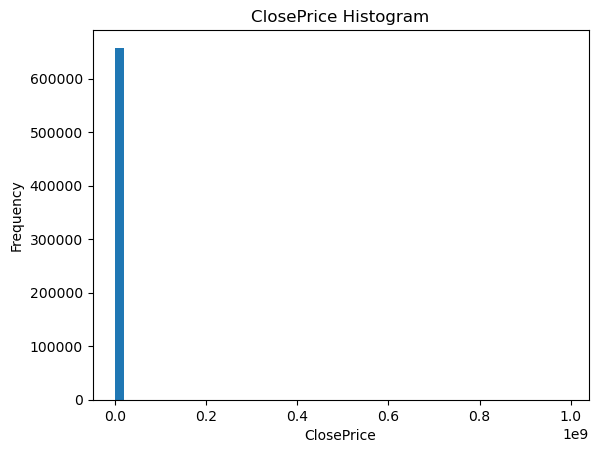

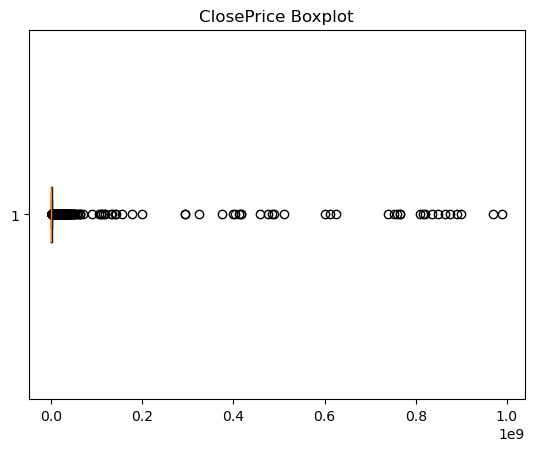


===== ListPrice =====
Percentiles:
count      657360.00
mean       837023.74
std       1264740.85
min             0.00
1%           1795.00
5%           2700.00
25%         64990.00
50%        629000.00
75%       1050000.00
95%       2498000.00
99%       4998000.00
max     137500000.00
Name: ListPrice, dtype: float64


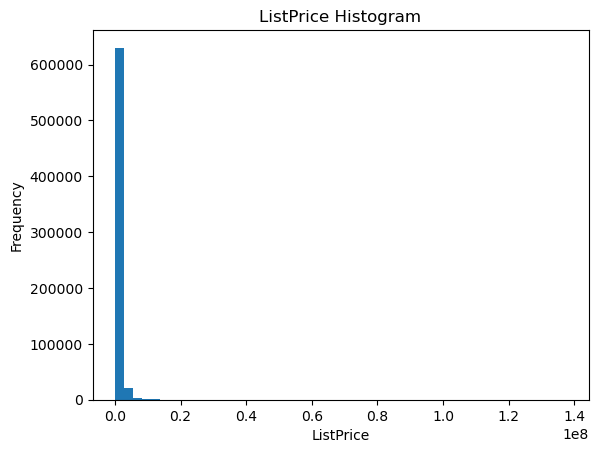

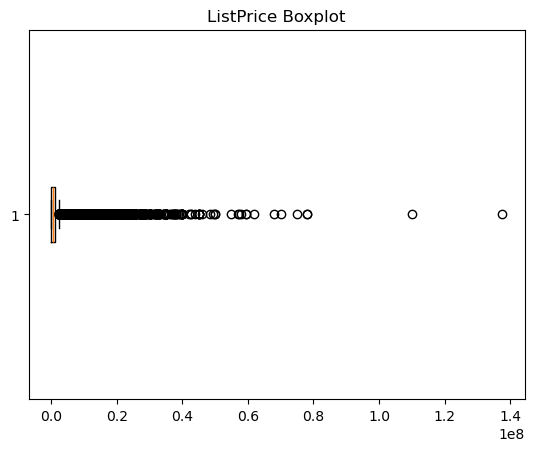


===== OriginalListPrice =====
Percentiles:
count       656437.00
mean        899503.26
std        5531567.14
min              0.00
1%            1800.00
5%            2750.00
25%          65000.00
50%         639000.00
75%        1080000.00
95%        2500000.00
99%        5289599.68
max     1390000000.00
Name: OriginalListPrice, dtype: float64


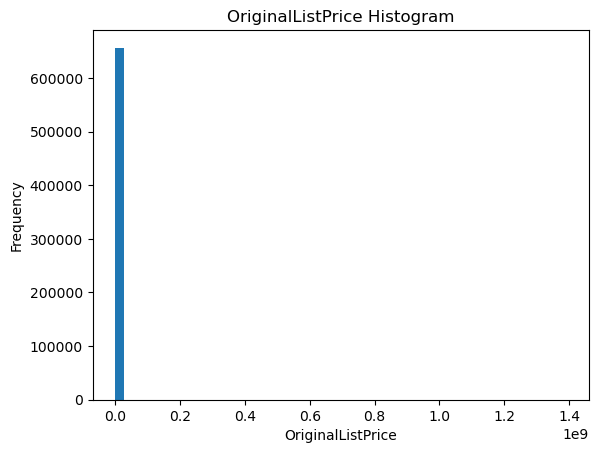

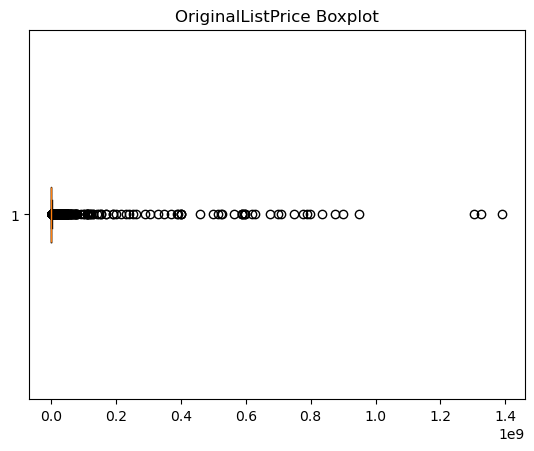


===== LivingArea =====
Percentiles:
count      611430.00
mean         3324.57
std       1162811.81
min             0.00
1%            481.00
5%            734.00
25%          1182.00
50%          1578.00
75%          2149.00
95%          3534.55
99%          5463.42
max     909090909.00
Name: LivingArea, dtype: float64


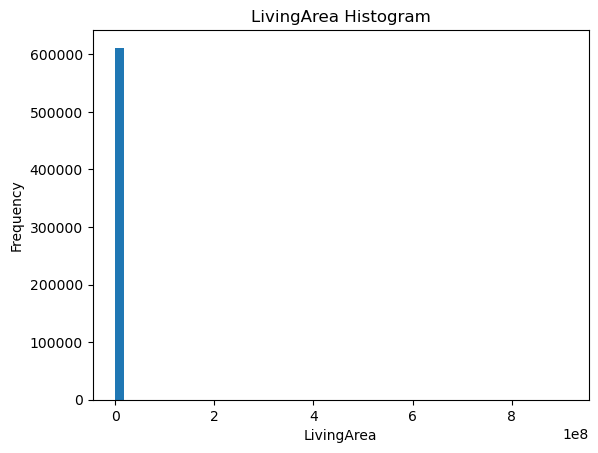

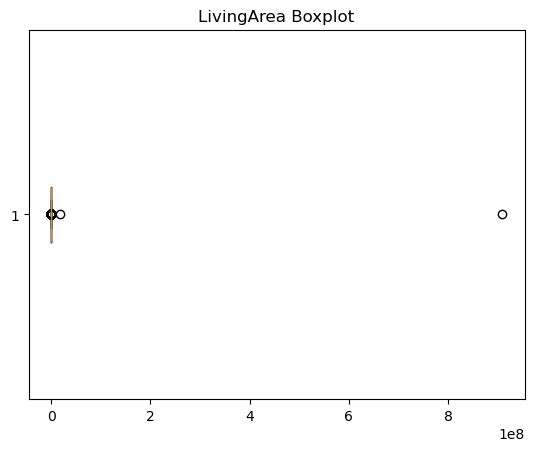


===== LotSizeAcres =====
Percentiles:
count      595429.00
mean          704.16
std        480125.87
min             0.00
1%              0.00
5%              0.03
25%             0.12
50%             0.17
75%             0.30
95%             3.57
99%            16.00
max     370260000.00
Name: LotSizeAcres, dtype: float64


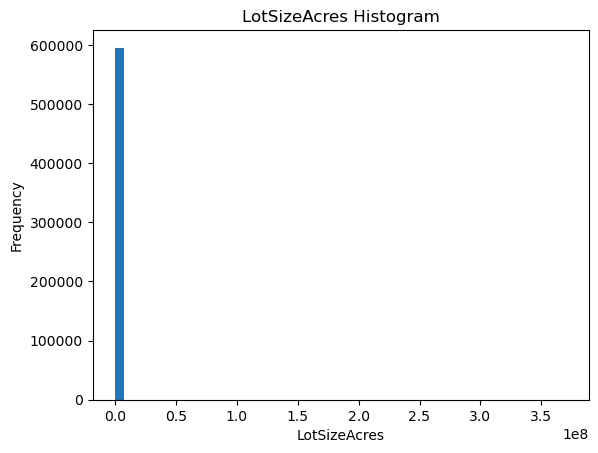

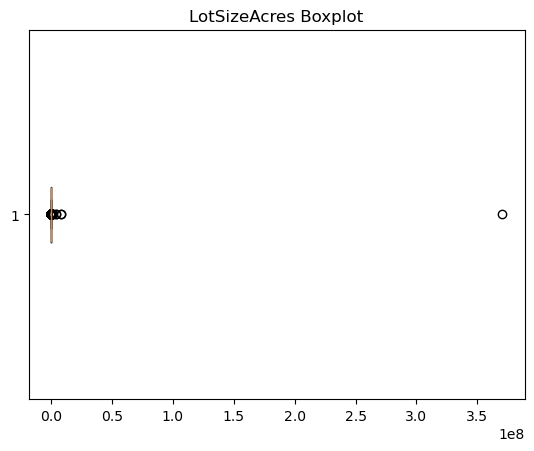


===== BedroomsTotal =====
Percentiles:
count   614019.00
mean         3.08
std          1.39
min          0.00
1%           1.00
5%           1.00
25%          2.00
50%          3.00
75%          4.00
95%          5.00
99%          6.00
max        123.00
Name: BedroomsTotal, dtype: float64


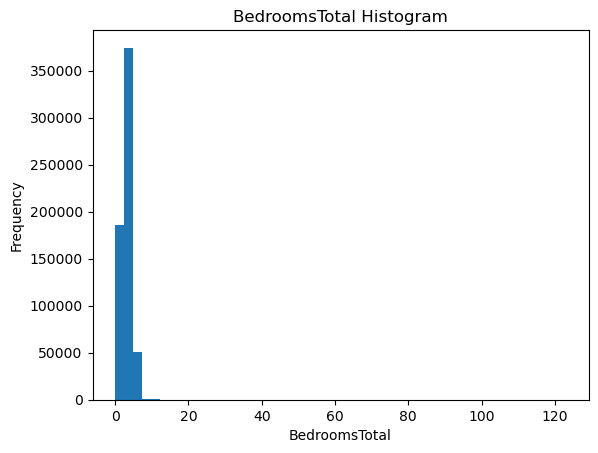

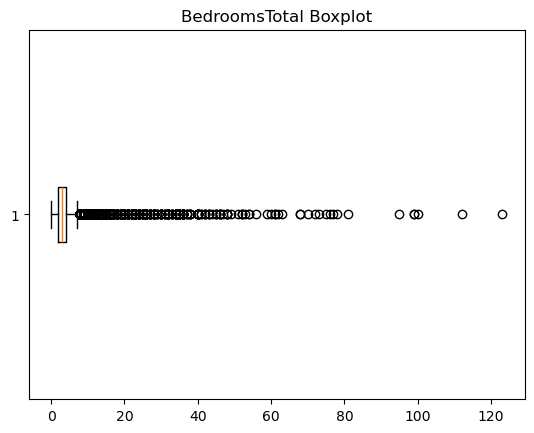


===== BathroomsTotalInteger =====
Percentiles:
count   627469.00
mean         2.44
std          1.40
min          0.00
1%           0.00
5%           1.00
25%          2.00
50%          2.00
75%          3.00
95%          4.00
99%          6.00
max        175.00
Name: BathroomsTotalInteger, dtype: float64


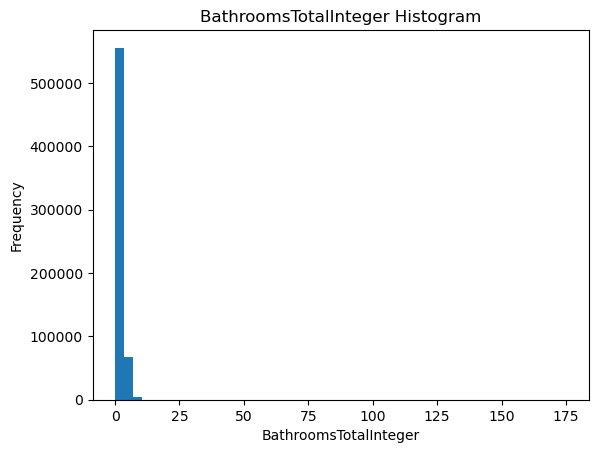

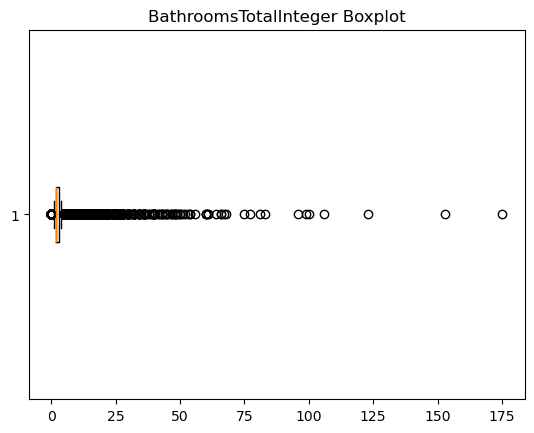


===== DaysOnMarket =====
Percentiles:
count   658362.00
mean        43.06
std         70.14
min       -288.00
1%           0.00
5%           2.00
25%          8.00
50%         22.00
75%         53.00
95%        147.00
99%        290.00
max      12430.00
Name: DaysOnMarket, dtype: float64


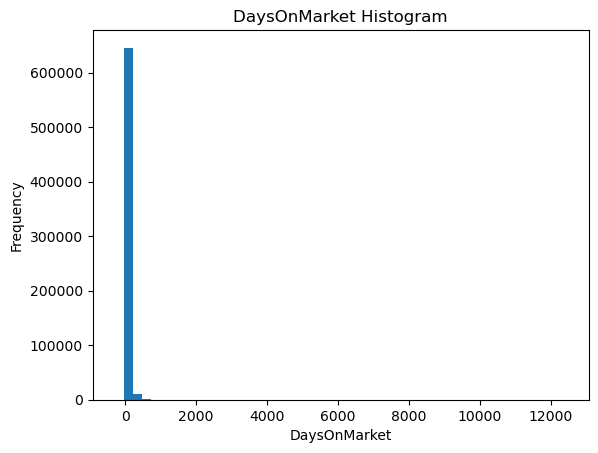

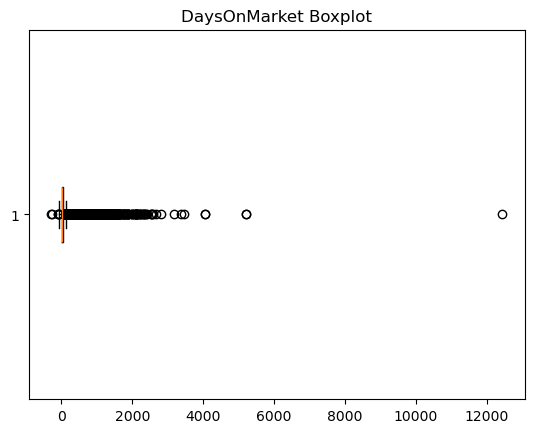


===== YearBuilt =====
Percentiles:
count   630247.00
mean      1978.14
std         27.06
min       1776.00
1%        1911.00
5%        1927.00
25%       1960.00
50%       1979.00
75%       1999.00
95%       2022.00
99%       2025.00
max       2026.00
Name: YearBuilt, dtype: float64


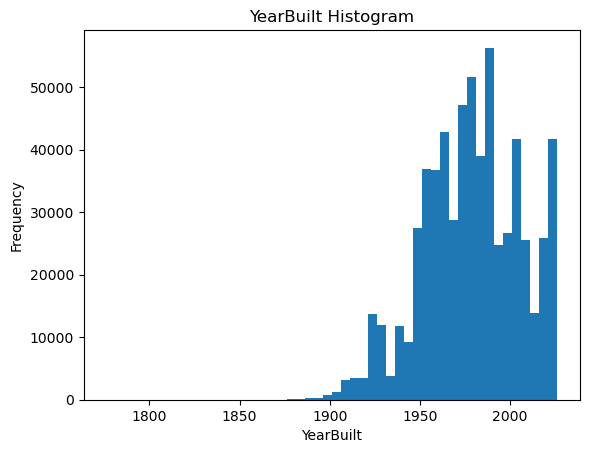

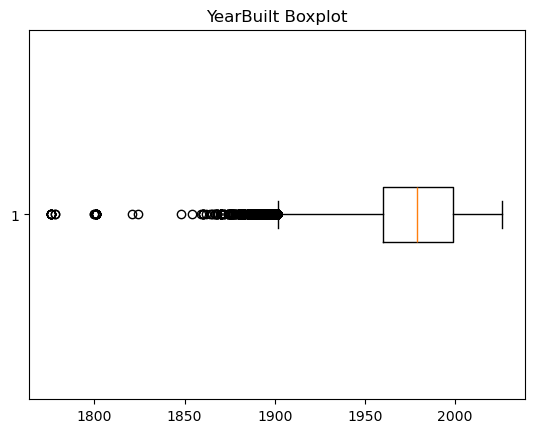

In [ ]:
# Looping
for col in numeric_cols:
    if col in sold_final.columns:
        print(f"\n===== {col} =====")

        # Drop missing values
        data = sold_final[col].dropna()

        # Percentile summary
        print("Percentiles:")
        print(data.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

        # Histogram
        plt.figure()
        plt.hist(data, bins=50)
        plt.title(f"{col} Histogram")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()

        # Boxplot
        plt.figure()
        plt.boxplot(data, vert=False)
        plt.title(f"{col} Boxplot")
        plt.show()

### Identify extreme outliers (IQR Method)

In [ ]:
outliers_dict = {}

for col in numeric_cols:
    if col in sold_final.columns:
        data = sold_final[col].dropna()

        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = data[(data < lower_bound) | (data > upper_bound)]

        outliers_dict[col] = len(outliers)

        print(f"{col}: {len(outliers)} outliers")

ClosePrice: 30640 outliers
ListPrice: 31271 outliers
OriginalListPrice: 30815 outliers
LivingArea: 28701 outliers
LotSizeAcres: 94508 outliers
BedroomsTotal: 2268 outliers
BathroomsTotalInteger: 41524 outliers
DaysOnMarket: 49458 outliers
YearBuilt: 1677 outliers


### Numeric Distribution Summary

In [ ]:
summary_cols = ["ClosePrice", "LivingArea", "DaysOnMarket"]

summary = (
    sold_final[summary_cols]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
    .T
)
print(summary)

                 count      mean        std     min      1%      5%      25%  \
ClosePrice   658355.00 867473.16 4932428.66    0.00 1750.00 2695.00 55000.00   
LivingArea   611430.00   3324.57 1162811.81    0.00  481.00  734.00  1182.00   
DaysOnMarket 658362.00     43.06      70.14 -288.00    0.00    2.00     8.00   

                   50%        75%        95%        99%          max  
ClosePrice   626000.00 1065000.00 2500000.00 4950000.00 989500000.00  
LivingArea     1578.00    2149.00    3534.55    5463.42 909090909.00  
DaysOnMarket     22.00      53.00     147.00     290.00     12430.00  


### Key Takeaways
- Heavily right-skewed
- ClosePrice: has small number of high-value properties significantly inflating the mean relative to the median, as indicated with extreme outliers
- LivingArea: similar indication, max is unrealistic, unless some commercial property slipped in
- DaysOnMarket: max days is HIGHLY unrealistic

This is expected in real estate datasets, where high-value properties and large land sizes create natural variability. These outliers will be carefully evaluated to determine appropriate handling methods.

### Suggested Intern Questions

In [ ]:
# What is the Residential vs. other property type share?
# Need to used orginal listing_combined to get the full picture of all property types, not just residential
property_summary = (
    listing_final['PropertyType']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
print(property_summary)

PropertyType
Residential           63.34
ResidentialLease      20.86
Land                   6.62
ResidentialIncome      3.71
ManufacturedInPark     2.88
CommercialSale         1.37
CommercialLease        0.91
BusinessOpportunity    0.32
Name: proportion, dtype: float64


In [ ]:
# What are the median and average close prices?
median_price = round(sold_final['ClosePrice'].median(), 2)
mean_price = round(sold_final['ClosePrice'].mean(), 2)

print("Median Close Price:", median_price)
print("Average Close Price:", mean_price)

Median Close Price: 626000.0
Average Close Price: 867473.16


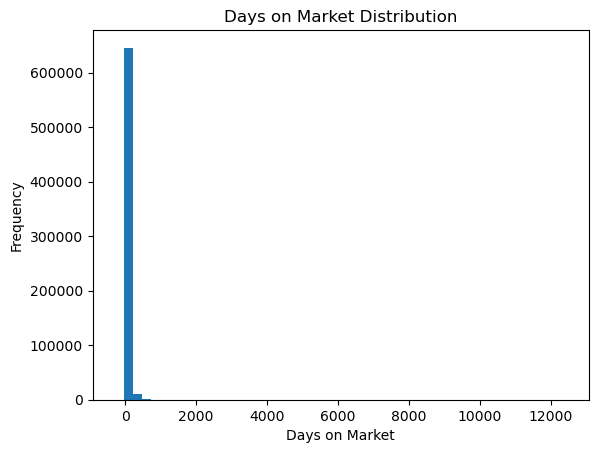

In [ ]:
# What does the Days on Market distribution look like?

sold_final['DaysOnMarket'].plot(kind='hist', bins=50)
plt.title("Days on Market Distribution")
plt.xlabel("Days on Market")
plt.ylabel("Frequency")
plt.show()

In [ ]:
sold_final['DaysOnMarket'].describe()

count   658362.00
mean        43.06
std         70.14
min       -288.00
25%          8.00
50%         22.00
75%         53.00
max      12430.00
Name: DaysOnMarket, dtype: float64

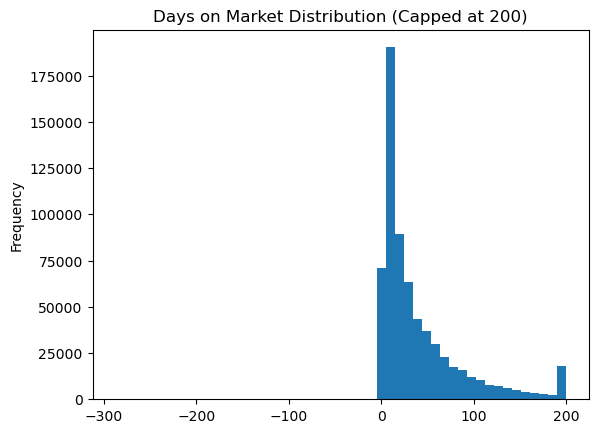

In [ ]:
# Removing outliers by capping at 200 days on market to see the distribution more clearly
sold_final['DaysOnMarket'].clip(upper=200).plot(kind='hist', bins=50)
plt.title("Days on Market Distribution (Capped at 200)")
plt.show()

The distribution of Days on Market is right-skewed, with most properties selling within a relatively short time frame. The median is lower than the mean, indicating the presence of outliers where some properties remain on the market significantly longer.
- Most homes sell quickly
- A few take much longer thus a skew
- The market is not evenly distributed

In [ ]:
# What percentage of homes sold above vs. below list price?
sdf = sold_final

sdf['Above_List'] = sdf['ClosePrice'] > sdf['ListPrice']

# calculate the percentage of homes sold above vs. below list price
price_comparison = sdf['Above_List'].value_counts(normalize=True) * 100

print(price_comparison)

# ~41% of homes sold above list price, while ~59% sold at or below list price.

Above_List
False   68.90
True    31.10
Name: proportion, dtype: float64


In [ ]:
# Are there any apparent date consistency issues (e.g., close date before listing date)?

# We can check for date consistency by comparing the 'CloseDate' and 'ListDate' columns. If there are any rows where 'CloseDate' is before 'ListDate', that would indicate a potential issue.
sdf['CloseDate'] = pd.to_datetime(sdf['CloseDate'], errors='coerce')
sdf['ListingContractDate'] = pd.to_datetime(sdf['ListingContractDate'], errors='coerce')

date_issues = sdf[sdf['CloseDate'] < sdf['ListingContractDate']]

print("Number of inconsistent records:", len(date_issues))

Number of inconsistent records: 122


In [ ]:
date_issues[['ListingContractDate', 'CloseDate']].head()

,ListingContractDate,CloseDate
721,2024-04-12,2024-04-04
25083,2024-09-13,2024-09-12
28878,2024-10-02,2024-09-19
29179,2024-09-30,2024-09-05
30015,2024-09-28,2024-09-24


In [ ]:
# percentage
date_issue_percentage = (len(date_issues) / len(sdf)) * 100
print(f"Percentage of date consistency issues: {date_issue_percentage:.2f}%")

Percentage of date consistency issues: 0.02%


A small number of records were identified where the close date precedes the listing date, indicating potential data entry or system errors. These records were flagged for further review or removal. Small % indicates normal data noise.

In [ ]:
# Which counties have the highest median prices?

# group by county, calculate median close price, and sort in descending order
county_median = (
    sdf.groupby('CountyOrParish')['ClosePrice']
    .median()
    .sort_values(ascending=False)
)

print(county_median.head(10))

CountyOrParish
Santa Clara       1499333.00
San Mateo         1450000.00
Alpine            1100000.00
San Francisco     1086250.00
Alameda           1052000.00
Marin             1050000.00
Santa Cruz        1030000.00
Monterey           879000.00
San Diego          800300.00
San Luis Obispo    770000.00
Name: ClosePrice, dtype: float64


In [ ]:
# Table format for better readability
county_median_df = county_median.reset_index()
county_median_df.columns = ['County', 'Median Close Price']

print(county_median_df.head(10))

            County  Median Close Price
0      Santa Clara          1499333.00
1        San Mateo          1450000.00
2           Alpine          1100000.00
3    San Francisco          1086250.00
4          Alameda          1052000.00
5            Marin          1050000.00
6       Santa Cruz          1030000.00
7         Monterey           879000.00
8        San Diego           800300.00
9  San Luis Obispo           770000.00


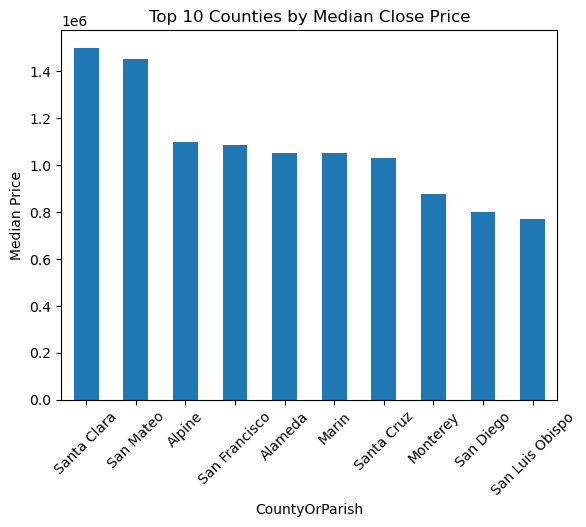

In [ ]:
county_median.head(10).plot(kind='bar')
plt.title("Top 10 Counties by Median Close Price")
plt.ylabel("Median Price")
plt.xticks(rotation=45)
plt.show()

### Save the filtered dataset as a new CSV.

In [ ]:
sold_final.to_csv("sold_final.csv", index=False)
listing_final.to_csv("listing_final.csv", index=False)

### Tasks

In [ ]:
# Inspect structure
sold_final.columns

Index(['ClosePrice', 'ListPrice', 'OriginalListPrice', 'CloseDate',
       'PurchaseContractDate', 'ListingContractDate',
       'ContractStatusChangeDate', 'DaysOnMarket', 'LivingArea',
       'BuildingAreaTotal', 'BedroomsTotal', 'BathroomsTotalInteger',
       'LotSizeAcres', 'LotSizeSquareFeet', 'YearBuilt', 'Stories', 'Levels',
       'GarageSpaces', 'ParkingTotal', 'FireplacesTotal', 'FireplaceYN',
       'NewConstructionYN', 'AttachedGarageYN', 'CoveredSpaces',
       'MainLevelBedrooms', 'AboveGradeFinishedArea', 'BelowGradeFinishedArea',
       'City', 'CountyOrParish', 'PostalCode', 'StateOrProvince', 'Latitude',
       'Longitude', 'UnparsedAddress', 'SubdivisionName', 'MLSAreaMajor',
       'PropertyType', 'PropertySubType', 'MlsStatus', 'Above_List',
       'year_month'],
      dtype='object')

In [ ]:
sold_final.head()

,ClosePrice,ListPrice,OriginalListPrice,CloseDate,PurchaseContractDate,ListingContractDate,ContractStatusChangeDate,DaysOnMarket,LivingArea,BuildingAreaTotal,...,Latitude,Longitude,UnparsedAddress,SubdivisionName,MLSAreaMajor,PropertyType,PropertySubType,MlsStatus,Above_List,year_month
2,250000.00,265000.00,265000.00,2024-04-02,2022-09-08,2021-09-15,2024-04-02,68,1723.00,NaN,...,36.78,-119.77,3533 Virginia Lane N,NaN,NaN,Residential,SingleFamilyResidence,Closed,False,2024-04
7,413700.00,414999.00,429000.00,2024-04-30,2021-09-05,2021-05-12,2024-04-30,64,2285.00,NaN,...,33.61,-116.47,68252 Materhorn,",IDK","326 - Pinyon Pines, Garner Valley",Residential,SingleFamilyResidence,Closed,False,2024-04
12,725000.00,750000.00,600000.00,2024-04-03,2024-02-21,2023-10-04,2024-04-03,254,1716.00,NaN,...,32.55,-117.05,2378 Smythe Avenue,NaN,92173 - San Ysidro,Residential,SingleFamilyResidence,Closed,False,2024-04
25,600000.00,600000.00,600000.00,2024-04-12,2024-04-03,2024-02-15,2024-04-12,0,1600.00,NaN,...,32.74,-116.99,3457 Kenora Dr,Spring Valley,91977 - Spring Valley,Residential,SingleFamilyResidence,Closed,False,2024-04
26,600000.00,575000.00,575000.00,2024-04-08,2024-04-07,2024-04-07,2024-04-08,0,1726.00,NaN,...,37.71,-122.42,312 Argonaut Ave,NaN,NaN,Residential,NaN,Closed,True,2024-04


In [ ]:

# Check property categories
sold_final['PropertyType'].unique()


array(['Residential'], dtype=object)

In [ ]:
# Filter residential
sold_final = sold_final[sold_final.PropertyType == 'Residential']

In [ ]:
# Validate completeness
sold_final.isnull().sum()

ClosePrice                       2
ListPrice                        0
OriginalListPrice              824
CloseDate                        0
PurchaseContractDate           198
ListingContractDate              1
ContractStatusChangeDate      1183
DaysOnMarket                     0
LivingArea                     249
BuildingAreaTotal           411482
BedroomsTotal                   12
BathroomsTotalInteger           80
LotSizeAcres                 35244
LotSizeSquareFeet            34829
YearBuilt                      389
Stories                      69182
Levels                       43673
GarageSpaces                 18918
ParkingTotal                   854
FireplacesTotal             442285
FireplaceYN                    337
NewConstructionYN            32676
AttachedGarageYN             67466
CoveredSpaces               442285
MainLevelBedrooms           186053
AboveGradeFinishedArea      442285
BelowGradeFinishedArea      439803
City                           360
CountyOrParish      

## Week 3 - Mortgage Rate Enrichment
- Enrich both the combined sold and listings datasets by merging in the national 30-year fixed mortgage rate from the St. Louis Federal Reserve (FRED).

In [ ]:
# Step 1 – Fetch mortgage data
url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=MORTGAGE30US"
mortgage = pd.read_csv(url, parse_dates=['observation_date'])
mortgage.columns = ['date', 'rate_30yr_fixed']

# Step 2 – Convert to monthly average
mortgage['year_month'] = mortgage['date'].dt.to_period('M')

mortgage_monthly = (
    mortgage.groupby('year_month')['rate_30yr_fixed']
    .mean()
    .reset_index()
)

# Step 3 – Create matching key in your datasets

# SOLD dataset
sold_final['year_month'] = pd.to_datetime(
    sold_final['CloseDate'], errors='coerce'
).dt.to_period('M')

# LISTING dataset
listing_final['year_month'] = pd.to_datetime(
    listing_final['ListingContractDate'], errors='coerce'
).dt.to_period('M')

# Step 4 – Merge
sold_with_rates = sold_final.merge(
    mortgage_monthly, on='year_month', how='left'
)

listing_with_rates = listing_final.merge(
    mortgage_monthly, on='year_month', how='left'
)

# Step 5 – Validate
print("Missing sold rates:", sold_with_rates['rate_30yr_fixed'].isnull().sum())
print("Missing listing rates:", listing_with_rates['rate_30yr_fixed'].isnull().sum())

# Preview
print(
    sold_with_rates[
        ['CloseDate', 'year_month', 'ClosePrice', 'rate_30yr_fixed']
    ].head()
)

Missing sold rates: 0
Missing listing rates: 0
   CloseDate year_month  ClosePrice  rate_30yr_fixed
0 2024-04-29    2024-04    45000.00             6.99
1 2024-04-26    2024-04    78000.00             6.99
2 2024-04-02    2024-04   250000.00             6.99
3 2024-04-10    2024-04   815000.00             6.99
4 2024-04-06    2024-04    15000.00             6.99
